# Deep Ensemble vs MC Dropout

Train 10 EfficientNet-B0 models on the full training set (different seeds).
Then compare two ways of producing 10 predictions per test sample:

- **MC Dropout:** Take **model 0** only and run **T=10 stochastic forward passes** with dropout enabled.
- **Deep Ensemble:** Run **all 10 models** with dropout **off** (one deterministic pass each).

Compare **accuracy** and **variance of disagreement** across the 10 predictions.

In [1]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

NUM_CLASSES = 30
N_MODELS = 10
T = 10                 # MC Dropout forward passes
EPOCHS = 10
BATCH_SIZE = 64
LR = 1e-4
SEED = 42
SAVE_DIR = Path("ensemble_10")
SAVE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, saving to {SAVE_DIR}")

Device: cuda, saving to ensemble_10


## 1. Train 10 Models on the Full Training Set

Different seed per model → different init, shuffling order, and dropout sampling.
Skips any model whose checkpoint already exists.

In [2]:
def build_model():
    return timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES,
                              drop_rate=0.2, drop_path_rate=0.2)

cfg = timm.data.resolve_model_data_config(build_model())
train_transform = timm.data.create_transform(**cfg, is_training=True)
val_transform = timm.data.create_transform(**cfg, is_training=False)

train_ds = datasets.ImageFolder("PrepData/Training", transform=train_transform)
val_ds = datasets.ImageFolder("PrepData/Validation", transform=val_transform)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

criterion = nn.CrossEntropyLoss()

for k in range(N_MODELS):
    path = SAVE_DIR / f"model_{k}.pth"
    if path.exists():
        print(f"Model {k}: already exists ({path}), skipping")
        continue

    print(f"\n=== Training Model {k+1}/{N_MODELS} (seed={SEED + k}) ===")
    torch.manual_seed(SEED + k)
    model = build_model().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    g = torch.Generator().manual_seed(SEED + k)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, generator=g)

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for images, t in tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS}", leave=False):
            images, t = images.to(device), t.to(device)
            outputs = model(images)
            loss = criterion(outputs, t)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, t in val_loader:
                images, t = images.to(device), t.to(device)
                correct += (model(images).argmax(1) == t).sum().item()
        val_acc = 100 * correct / len(val_ds)
        print(f"  Epoch {epoch+1}: Loss={train_loss/len(train_loader):.4f}, Val Acc={val_acc:.2f}%")

    torch.save(model.state_dict(), path)
    print(f"  Saved to {path}")


=== Training Model 1/10 (seed=42) ===


  Epoch 1/10:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1: Loss=4.0541, Val Acc=13.92%


  Epoch 2/10:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 2: Loss=3.1834, Val Acc=32.99%


...

  Epoch 8: Loss=1.3156, Val Acc=74.74%


  Epoch 9/10:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 9: Loss=0.9969, Val Acc=76.29%


  Epoch 10/10:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 10: Loss=0.8906, Val Acc=76.80%
  Saved to ensemble_10/model_9.pth


## 2. Test Data

In [3]:
test_ds = datasets.ImageFolder("PrepData/Test", transform=val_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

test_labels = torch.tensor(test_ds.targets)
print(f"Test samples: {len(test_ds)}")

Test samples: 195


## 3. MC Dropout (Model 0, T=10 Stochastic Passes)

In [4]:
def enable_mc_dropout(model):
    model.eval()
    for module in model.modules():
        if "Drop" in type(module).__name__:
            module.train()
    return model

model0 = build_model().to(device)
model0.load_state_dict(torch.load(SAVE_DIR / "model_0.pth", map_location=device))
enable_mc_dropout(model0)

mc_passes = []
for t in tqdm(range(T), desc="MC Dropout passes"):
    batch_probs = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            batch_probs.append(F.softmax(model0(images), dim=1).cpu())
    mc_passes.append(torch.cat(batch_probs))

mc_all = torch.stack(mc_passes)          # (T, N, C)
mc_mean = mc_all.mean(dim=0)              # (N, C)
mc_preds = mc_mean.argmax(dim=1)
mc_acc = accuracy_score(test_labels, mc_preds)

# Variance of disagreement: mean variance of softmax across T passes
mc_variance = mc_all.var(dim=0).mean(dim=1)  # (N,)

print(f"MC Dropout Accuracy: {mc_acc:.2%}")
print(f"Mean Variance:       {mc_variance.mean():.6f}")

MC Dropout passes:   0%|          | 0/10 [00:00<?, ?it/s]

MC Dropout Accuracy: 78.46%
Mean Variance:       0.000640


## 4. Deep Ensemble (10 Models, Dropout Off)

In [5]:
ens_passes = []
for k in tqdm(range(N_MODELS), desc="Ensemble models"):
    model = build_model().to(device)
    model.load_state_dict(torch.load(SAVE_DIR / f"model_{k}.pth", map_location=device))
    model.eval()  # dropout OFF
    batch_probs = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            batch_probs.append(F.softmax(model(images), dim=1).cpu())
    ens_passes.append(torch.cat(batch_probs))

ens_all = torch.stack(ens_passes)        # (N_MODELS, N, C)
ens_mean = ens_all.mean(dim=0)            # (N, C)
ens_preds = ens_mean.argmax(dim=1)
ens_acc = accuracy_score(test_labels, ens_preds)

ens_variance = ens_all.var(dim=0).mean(dim=1)  # (N,)

print(f"Deep Ensemble Accuracy: {ens_acc:.2%}")
print(f"Mean Variance:          {ens_variance.mean():.6f}")

Ensemble models:   0%|          | 0/10 [00:00<?, ?it/s]

Deep Ensemble Accuracy: 82.56%
Mean Variance:          0.002379


## 5. Comparison: Accuracy and Variance of Disagreement

In [6]:
print(f"=== Accuracy ===")
print(f"  MC Dropout (model 0, T={T}):      {mc_acc:.2%}")
print(f"  Deep Ensemble (N={N_MODELS} models): {ens_acc:.2%}")
print(f"\n=== Variance (mean across samples) ===")
print(f"  MC Dropout:    {mc_variance.mean():.6f}")
print(f"  Deep Ensemble: {ens_variance.mean():.6f}")
print(f"\n=== Variance on correct vs misclassified samples ===")
for name, preds, var in [("MC Dropout", mc_preds, mc_variance),
                          ("Deep Ensemble", ens_preds, ens_variance)]:
    correct = preds == test_labels
    v_c = var[correct].mean().item()
    v_w = var[~correct].mean().item() if (~correct).any() else float('nan')
    print(f"  {name:15s}  Correct={v_c:.6f}   Wrong={v_w:.6f}   Ratio={v_w/v_c:.2f}x")

=== Accuracy ===
  MC Dropout (model 0, T=10):      78.46%
  Deep Ensemble (N=10 models): 82.56%

=== Variance (mean across samples) ===
  MC Dropout:    0.000640
  Deep Ensemble: 0.002379

=== Variance on correct vs misclassified samples ===
  MC Dropout       Correct=0.000564   Wrong=0.000917   Ratio=1.63x
  Deep Ensemble    Correct=0.001957   Wrong=0.004377   Ratio=2.24x


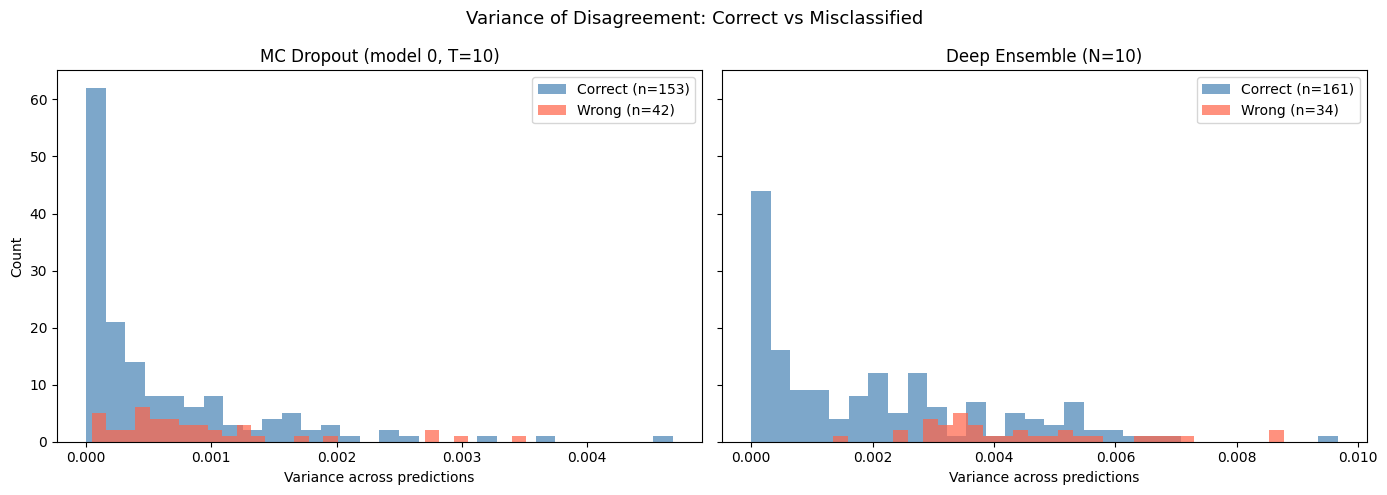

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, name, preds, var in [(axes[0], f"MC Dropout (model 0, T={T})", mc_preds, mc_variance),
                              (axes[1], f"Deep Ensemble (N={N_MODELS})", ens_preds, ens_variance)]:
    correct = preds == test_labels
    ax.hist(var[correct].numpy(), bins=30, alpha=0.7, label=f"Correct (n={correct.sum()})", color='steelblue')
    if (~correct).any():
        ax.hist(var[~correct].numpy(), bins=30, alpha=0.7, label=f"Wrong (n={(~correct).sum()})", color='tomato')
    ax.set_xlabel("Variance across predictions")
    ax.set_title(name)
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Variance of Disagreement: Correct vs Misclassified", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Top 10 Most Uncertain Samples

For each method, show the 10 test images with the highest variance of disagreement,
with top-5 mean probabilities.

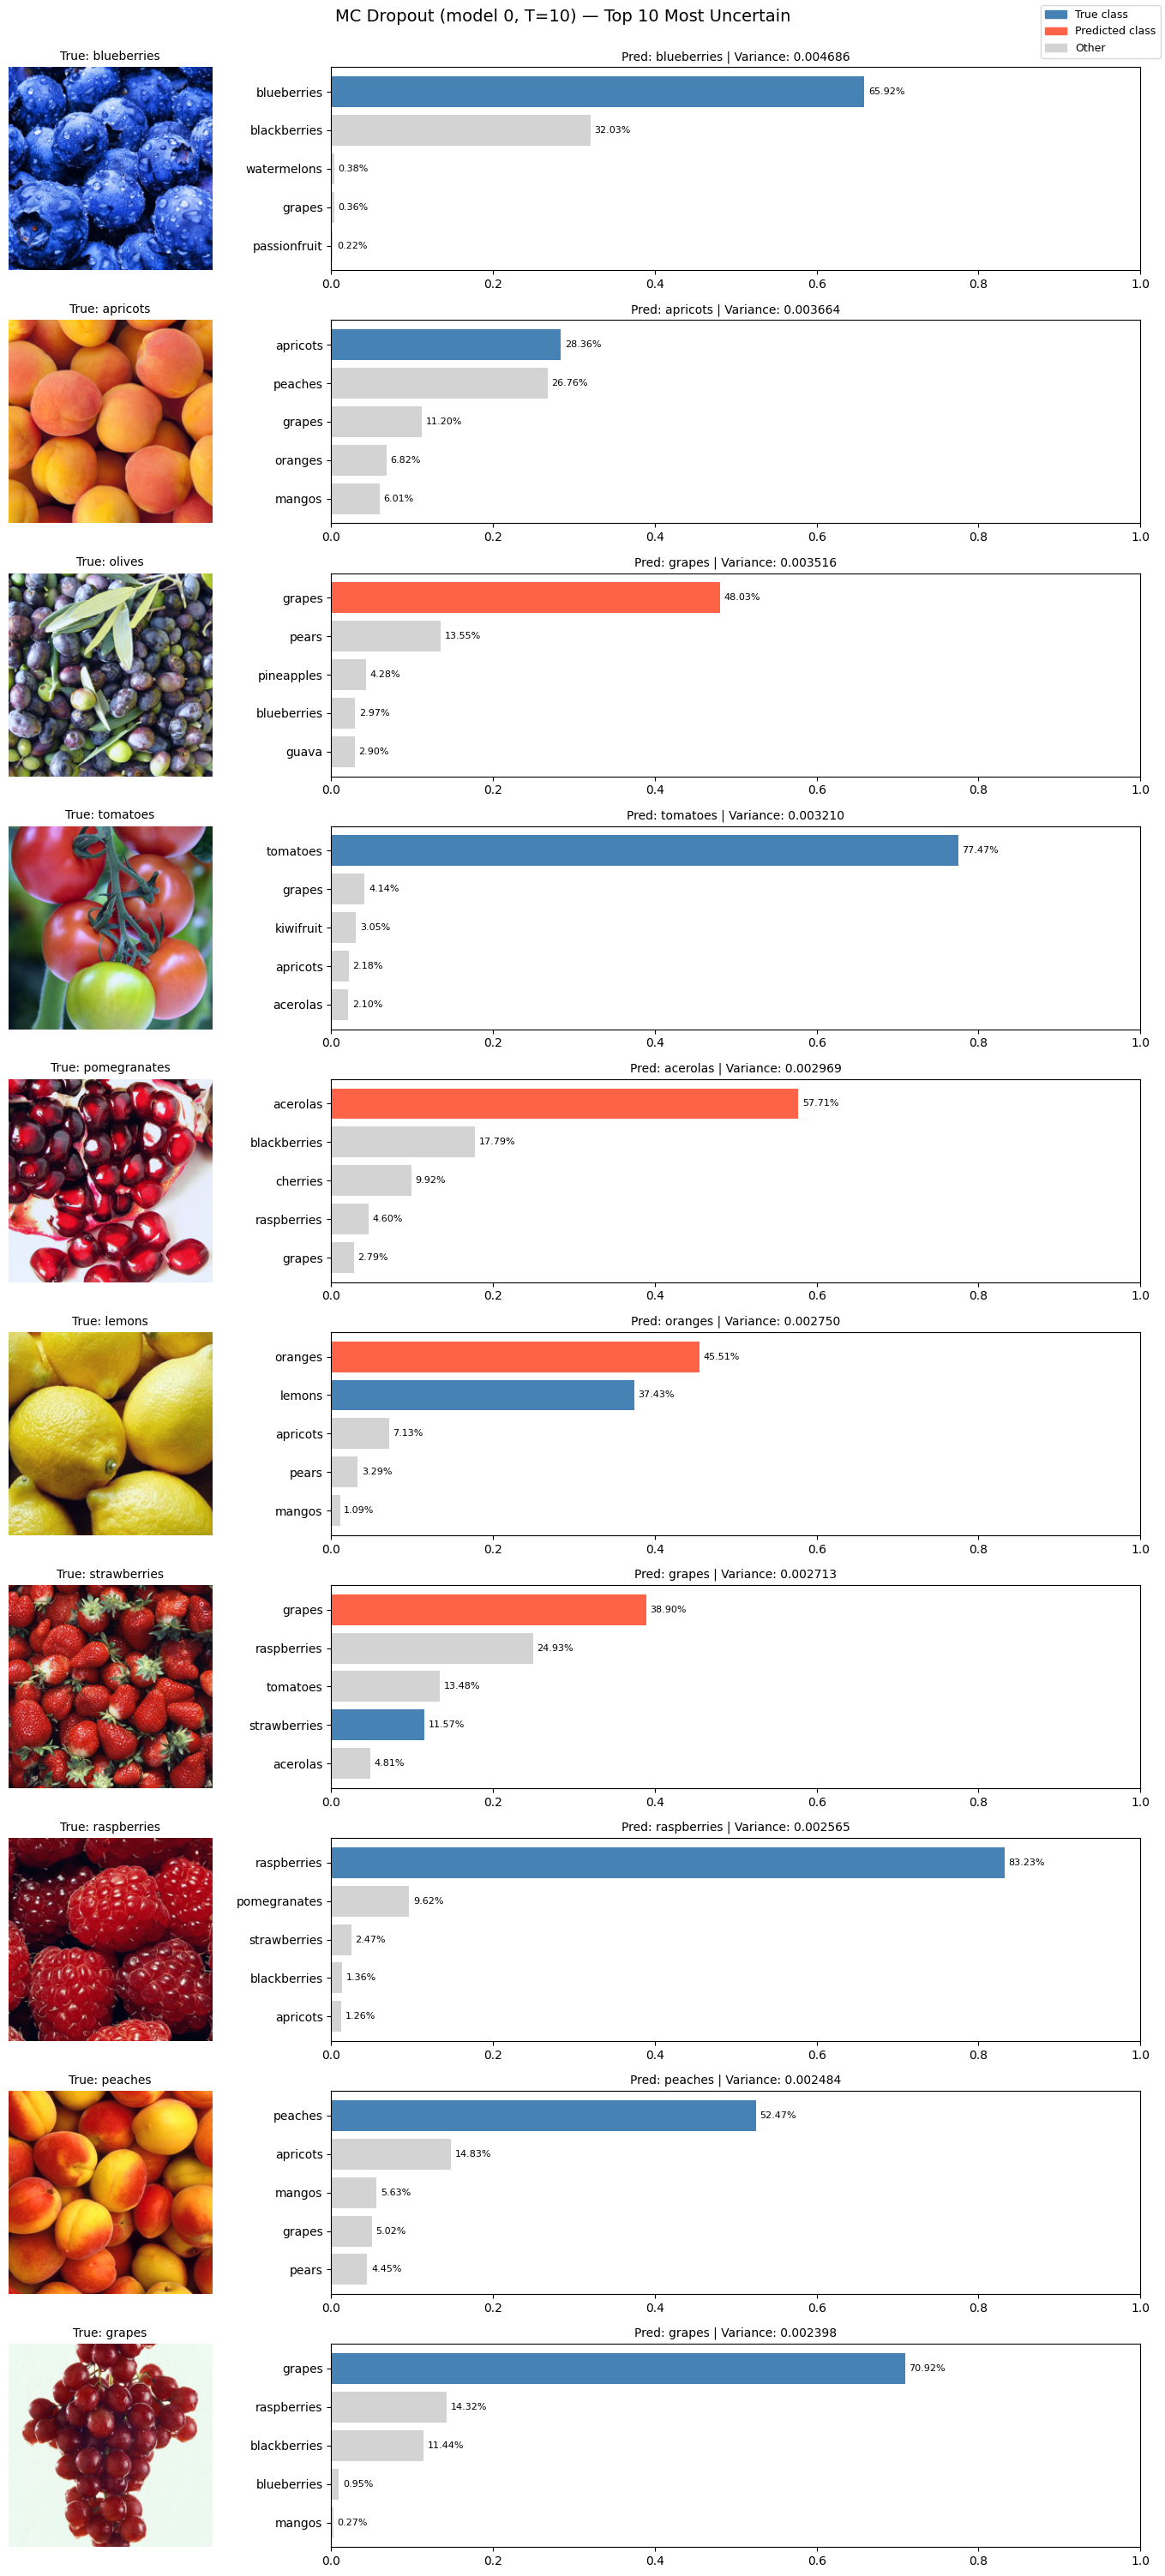

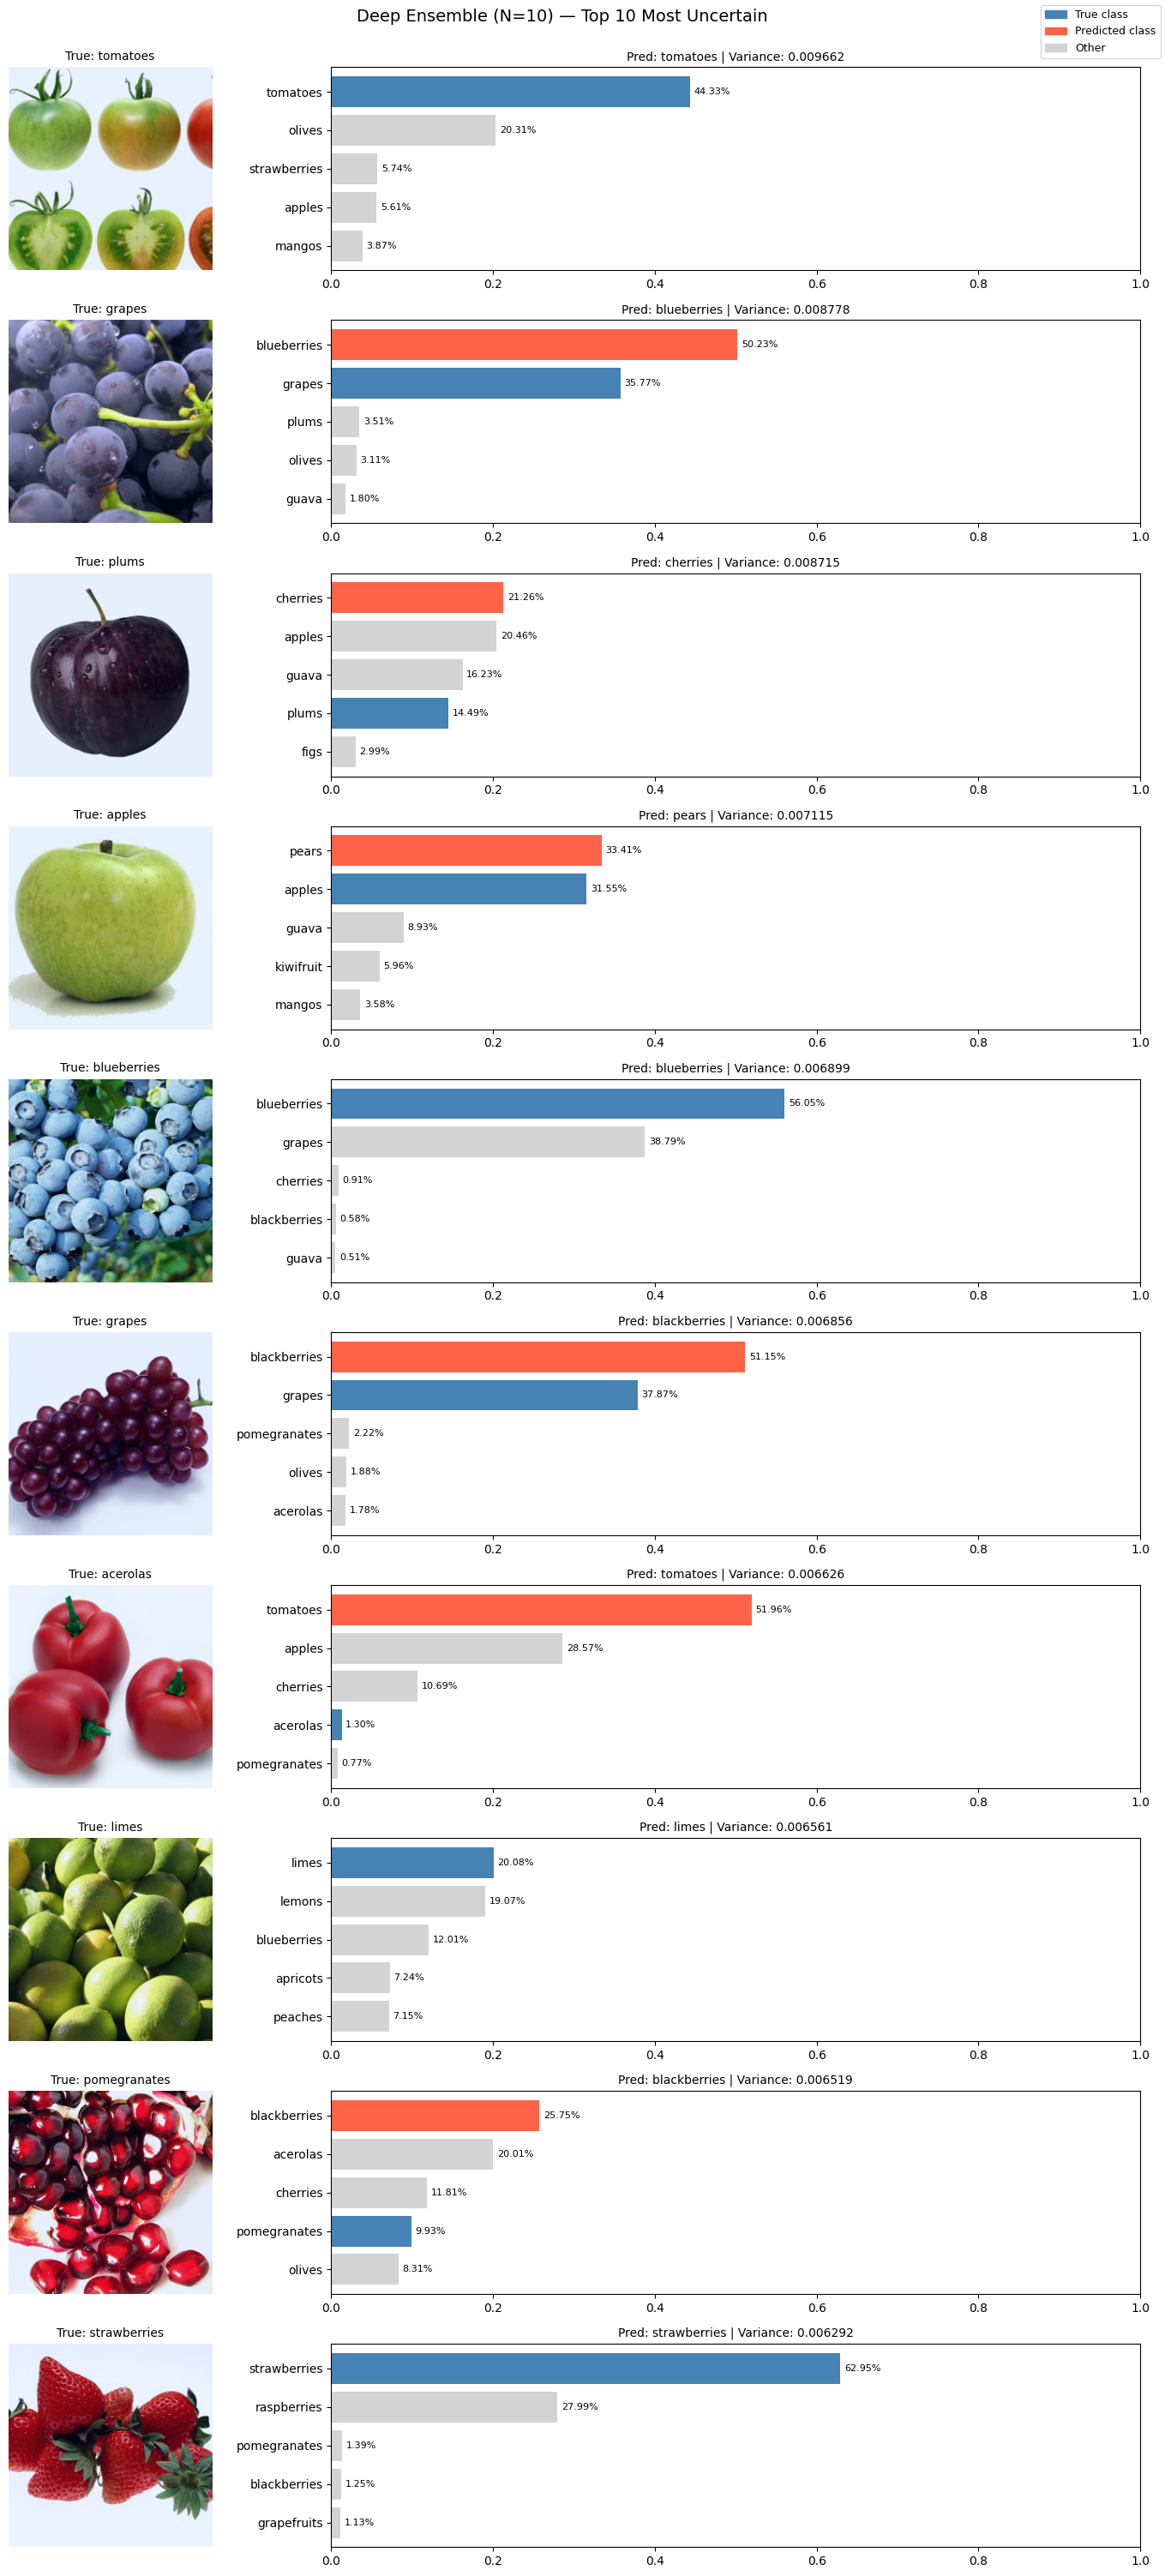

In [8]:
def denorm_image(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

# Collect test images once
all_test_images = []
for images, _ in test_loader:
    all_test_images.append(images)
all_test_images = torch.cat(all_test_images)

class_names = test_ds.classes


def plot_top_uncertain(variance, mean_probs, preds, title, top_k=10):
    from matplotlib.patches import Patch
    indices = variance.argsort(descending=True)[:top_k].tolist()
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3 * n),
                             gridspec_kw={"width_ratios": [1, 3]})
    fig.suptitle(title, fontsize=14, y=1.0)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, idx in enumerate(indices):
        true_label = test_labels[idx].item()
        pred_label = preds[idx].item()
        mean_p = mean_probs[idx]
        var = variance[idx].item()

        top5_idx = mean_p.argsort(descending=True)[:5]
        top5_names = [class_names[i] for i in top5_idx]
        top5_probs = mean_p[top5_idx].numpy()

        colors = []
        for i in top5_idx:
            if i == true_label and i == pred_label:
                colors.append('steelblue')
            elif i == pred_label:
                colors.append('tomato')
            elif i == true_label:
                colors.append('steelblue')
            else:
                colors.append('lightgray')

        axes[row, 0].imshow(denorm_image(all_test_images[idx]))
        axes[row, 0].set_title(f"True: {class_names[true_label]}", fontsize=10)
        axes[row, 0].axis('off')

        bars = axes[row, 1].barh(top5_names[::-1], top5_probs[::-1], color=colors[::-1])
        for bar, val in zip(bars, top5_probs[::-1]):
            axes[row, 1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                              f"{val:.2%}", va='center', fontsize=8)
        axes[row, 1].set_xlim(0, 1)
        axes[row, 1].set_title(f"Pred: {class_names[pred_label]} | Variance: {var:.6f}", fontsize=10)

    legend_elements = [Patch(color='steelblue', label='True class'),
                       Patch(color='tomato', label='Predicted class'),
                       Patch(color='lightgray', label='Other')]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()


plot_top_uncertain(mc_variance, mc_mean, mc_preds,
                   f"MC Dropout (model 0, T={T}) — Top 10 Most Uncertain")
plot_top_uncertain(ens_variance, ens_mean, ens_preds,
                   f"Deep Ensemble (N={N_MODELS}) — Top 10 Most Uncertain")
